# Qiskit 101 — Lab 02

## Multi-Qubit Computing and Entanglement

### Overview

In Lab 01, we explored a **single qubit**. We learned how to prepare, manipulate, measure, and visualize states such as

$$
|0\rangle,\quad |1\rangle,\quad |+\rangle,\quad |-\rangle.
$$

Real quantum computations, however, require systems containing **multiple qubits**.

When qubits are combined, new computational possibilities emerge. In particular, quantum systems can exhibit **entanglement** — correlations that cannot be described simply by assigning an independent quantum state to each qubit.

In this lab, we will move from a single-qubit state

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle
$$

to two-qubit states such as

$$
|00\rangle,\quad |01\rangle,\quad |10\rangle,\quad |11\rangle
$$

and finally construct the Bell state

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

This state will provide our first practical example of **quantum entanglement**.

### Learning Objectives

By the end of this lab, you should be able to:

1. Create quantum circuits containing multiple qubits.
2. Interpret two-qubit computational-basis states.
3. Explain why two qubits require four probability amplitudes.
4. Construct product states using single-qubit gates.
5. Apply controlled operations such as CNOT.
6. Explain the roles of the **control** and **target** qubits.
7. Create a Bell state using H and CNOT.
8. Measure and interpret correlations between entangled qubits.
9. Obtain and interpret a two-qubit statevector.
10. Distinguish between a product state and an entangled state.
11. Construct the four Bell states.
12. Design and analyze a simple multi-qubit circuit.

### Learning Approach

Throughout the lab, follow:

> **Predict → Build → Execute → Observe → Explain**

Do not begin by asking only *“What output did Qiskit produce?”*

Instead ask:

> **“Why should this circuit produce this quantum state and these measurement outcomes?”**


## 1. Creating a Two-Qubit Quantum Circuit

A Qiskit circuit can contain any number of qubits.

In Lab 01, we created a single qubit using:

`QuantumCircuit(1)`

To create a system containing two qubits, we use:

`QuantumCircuit(2)`

The qubits are labelled:

$$
q_0,\qquad q_1.
$$

When a quantum circuit is initialized, every qubit starts in the state \(|0\rangle\).

Therefore, a two-qubit circuit initially represents

$$
|00\rangle.
$$

At this point, no quantum gates have been applied.

### Predict

If both qubits are measured immediately, what two-bit result should be obtained?

Will the result be deterministic or probabilistic?


In [ ]:
%pip install -q "qiskit[visualization]" pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 71.2 MB/s eta 0:00:00


In [ ]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.5.2


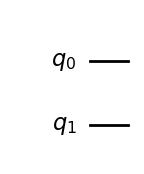

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.draw("mpl")

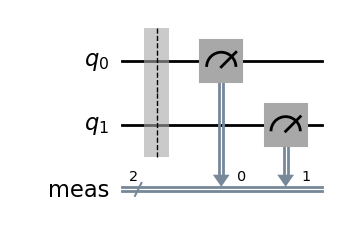

In [ ]:
qc.measure_all()

qc.draw("mpl")

In [ ]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([qc], shots=1024)
result = job.result()

counts = result[0].data.meas.get_counts()

print(counts)

{'00': 1024}


## 2. Two-Qubit Computational-Basis States

A single qubit has two computational-basis states:

$$
|0\rangle,\qquad |1\rangle.
$$

A system of **two qubits** has four computational-basis states:

$$
|00\rangle,\quad
|01\rangle,\quad
|10\rangle,\quad
|11\rangle.
$$

Therefore, a general two-qubit state requires **four probability amplitudes**:

$$
|\psi\rangle
=
\alpha|00\rangle+
\beta|01\rangle+
\gamma|10\rangle+
\delta|11\rangle,
$$

where

$$
|\alpha|^2+
|\beta|^2+
|\gamma|^2+
|\delta|^2=1.
$$

The corresponding statevector therefore contains four elements:

$$
|\psi\rangle=
\begin{bmatrix}
\alpha\\
\beta\\
\gamma\\
\delta
\end{bmatrix}.
$$

This illustrates an important scaling property of quantum systems:

* 1 qubit → \(2^1=2\) amplitudes
* 2 qubits → \(2^2=4\) amplitudes
* 3 qubits → \(2^3=8\) amplitudes
* \(n\) qubits → \(2^n\) amplitudes

### Important Qiskit Convention

Qiskit displays computational-basis bit strings with the **highest-index qubit on the left**.

For two qubits, the displayed string is therefore interpreted as

$$
q_1q_0.
$$

This convention becomes important when interpreting measurement counts and statevectors.


## 3. Preparing Two-Qubit Basis States

Starting from

$$
|00\rangle,
$$

we can use X gates to prepare the other computational-basis states.

Investigate how applying X to different qubits changes the two-qubit state.

### Task

Construct circuits that prepare:

$$
|00\rangle,\quad
|01\rangle,\quad
|10\rangle,\quad
|11\rangle.
$$

For each circuit:

1. Predict which X gates are required.
2. Draw the circuit.
3. Measure both qubits.
4. Execute for 1,024 shots.
5. Verify the result.
6. Explain the result using Qiskit's bit-ordering convention.


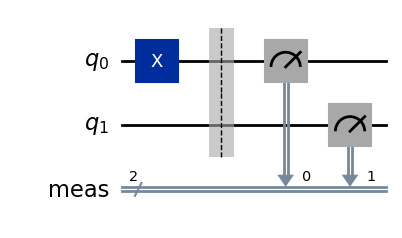

In [ ]:
qc = QuantumCircuit(2)

qc.x(0)
qc.measure_all()

qc.draw("mpl")

## 4. The Controlled-NOT (CNOT) Gate

Multi-qubit quantum circuits can contain operations whose behavior depends on the state of another qubit.

One of the most important is the **Controlled-NOT**, or **CNOT**, gate.

CNOT operates on two qubits:

* one **control qubit**
* one **target qubit**

If the control qubit is

$$
|0\rangle,
$$

the target is unchanged.

If the control qubit is

$$
|1\rangle,
$$

the target is flipped:

$$
|0\rangle\leftrightarrow|1\rangle.
$$

Its computational-basis behavior is

$$
|00\rangle\rightarrow|00\rangle
$$

$$
|01\rangle\rightarrow|11\rangle
$$

$$
|10\rangle\rightarrow|10\rangle
$$

$$
|11\rangle\rightarrow|01\rangle,
$$

when \(q_0\) is the control and \(q_1\) is the target and the ket is written in Qiskit's displayed \(q_1q_0\) order.

In Qiskit:

`qc.cx(control, target)`

For example:

`qc.cx(0, 1)`

means:

$$
q_0=\text{control},
\qquad
q_1=\text{target}.
$$

### Predict

Starting from \(|00\rangle\), what will

`cx(0,1)`

do?

Why?


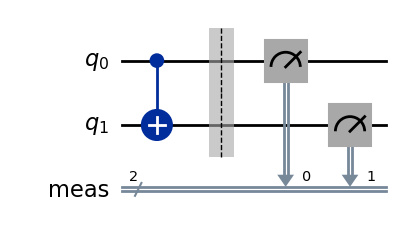

In [ ]:
qc = QuantumCircuit(2)

qc.cx(0, 1)
qc.measure_all()

qc.draw("mpl")

In [ ]:
qc.x(0)
qc.cx(0, 1)

## 5. Creating Our First Entangled State

Now we combine two operations that we already understand:

1. Hadamard
2. CNOT

Start from

$$
|00\rangle.
$$

Apply H to \(q_0\):

$$
|00\rangle
\rightarrow
\frac{|00\rangle+|01\rangle}{\sqrt2}
$$

using Qiskit's \(q_1q_0\) ordering.

The control qubit \(q_0\) is now in superposition.

Next apply

$$
CX(q_0,q_1).
$$

The component in which \(q_0=0\) leaves \(q_1\) unchanged, while the component in which \(q_0=1\) flips \(q_1\).

Therefore,

$$
\frac{|00\rangle+|01\rangle}{\sqrt2}
\rightarrow
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

The resulting state is the Bell state

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

This is an **entangled state**.

### Predict

Before measuring:

1. What two outcomes should be possible?
2. What probabilities should they have?
3. Should `01` or `10` ever occur on an ideal simulator?
4. If the first measured qubit is 0, what should we know about the other?


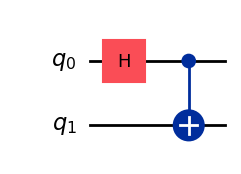

In [ ]:
qc_bell = QuantumCircuit(2)

qc_bell.h(0)
qc_bell.cx(0, 1)

qc_bell.draw("mpl")

In [ ]:
from qiskit.quantum_info import Statevector

bell_state = Statevector.from_instruction(qc_bell)

print(bell_state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [ ]:
qc_bell.measure_all()

job = sampler.run([qc_bell], shots=10000)
result = job.result()

counts_bell = result[0].data.meas.get_counts()

print(counts_bell)

{'00': 5006, '11': 4994}


In [ ]:
qc_product = QuantumCircuit(2)
qc_product.h(0)
qc_product.h(1)

In [ ]:
qc_entangled = QuantumCircuit(2)
qc_entangled.h(0)
qc_entangled.cx(0, 1)

## 6. Measuring and Analyzing Entanglement

In the previous section, we created the Bell state

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

using the circuit

$$
|00\rangle
\xrightarrow{H(q_0)}
\frac{|00\rangle+|01\rangle}{\sqrt2}
\xrightarrow{CX(q_0,q_1)}
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

The Bell state is not simply a state in which each qubit independently has a 50% probability of being 0 or 1.

Instead, the two qubits are **correlated**.

When measured in the computational basis:

$$
P(00)=\frac12,
\qquad
P(11)=\frac12,
$$

while

$$
P(01)=P(10)=0.
$$

Thus, an individual measurement outcome is unpredictable, but the relationship between the two measured qubits is perfectly predictable:

> **If one qubit is measured as 0, the other is also 0. If one is measured as 1, the other is also 1.**

In this section, we will use Qiskit measurement results to investigate this correlation.


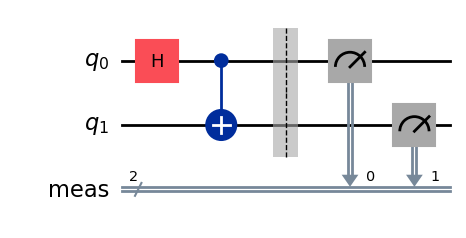

In [ ]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

# Create Bell state
qc_bell = QuantumCircuit(2)

qc_bell.h(0)
qc_bell.cx(0, 1)

# Measure both qubits
qc_bell.measure_all()

#print(qc_bell)
qc_bell.draw('mpl')

### 6.1 Predict Before Executing

Before executing the circuit, predict the measurement results.

The Bell state is

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

Therefore, answer the following:

1. Which two-bit outcomes are possible?
2. Which outcomes should never occur on an ideal simulator?
3. What is the theoretical probability of `00`?
4. What is the theoretical probability of `11`?
5. If \(q_0\) is measured as 1, what should be the value of \(q_1\)?

Write down your predictions before executing the circuit.


In [ ]:
sampler = StatevectorSampler()

job = sampler.run([qc_bell], shots=10000)
result = job.result()

counts_bell = result[0].data.meas.get_counts()

print(counts_bell)

{'11': 4946, '00': 5054}


In [ ]:
shots = sum(counts_bell.values())

p00 = counts_bell.get('00', 0) / shots
p01 = counts_bell.get('01', 0) / shots
p10 = counts_bell.get('10', 0) / shots
p11 = counts_bell.get('11', 0) / shots

print("P(00) =", p00)
print("P(01) =", p01)
print("P(10) =", p10)
print("P(11) =", p11)

P(00) = 0.5054
P(01) = 0.0
P(10) = 0.0
P(11) = 0.4946


### 6.2 Interpreting the Measurement Results

The individual outcome of the Bell-state measurement is probabilistic.

We cannot predict whether a particular shot will produce

$$
00
$$

or

$$
11.
$$

However, we can predict the **relationship between the two qubits**.

The two measured bits are always equal:

$$
q_0=q_1.
$$

Therefore:

* `00` → correlated
* `11` → correlated
* `01` → not expected
* `10` → not expected

This distinction is important:

> **The individual outcomes are random, but their correlation is deterministic.**

This is one of the characteristic features of the Bell state.


## 6.3 Is Superposition the Same as Entanglement?

Consider another two-qubit circuit.

Instead of applying H to one qubit followed by CNOT, apply H independently to **both qubits**:

$$
H(q_0),\qquad H(q_1).
$$

Each qubit becomes

$$
|+\rangle
=
\frac{|0\rangle+|1\rangle}{\sqrt2}.
$$

The combined state is

$$
|+\rangle|+\rangle
=
\frac{1}{2}
(
|00\rangle+
|01\rangle+
|10\rangle+
|11\rangle
).
$$

All four outcomes therefore have equal probability:

$$
P(00)=P(01)=P(10)=P(11)=\frac14.
$$

This is a **product state**.

Each qubit is in superposition, but the two qubits are not entangled.

Let us compare this state experimentally with the Bell state.


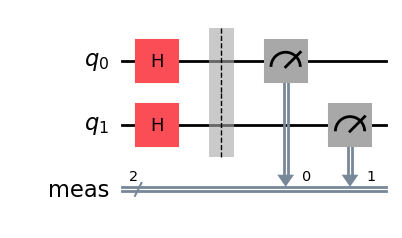

In [ ]:
qc_product = QuantumCircuit(2)

qc_product.h(0)
qc_product.h(1)

qc_product.measure_all()

qc_product.draw('mpl')

In [ ]:
job = sampler.run([qc_product], shots=10000)
result = job.result()

counts_product = result[0].data.meas.get_counts()

print(counts_product)

{'11': 2541, '01': 2491, '10': 2443, '00': 2525}


## 6.4 Product State vs Entangled State

We have now created two quantum states that both involve superposition.

### Independent Superpositions

$$
|+\rangle|+\rangle
=
\frac{
|00\rangle+
|01\rangle+
|10\rangle+
|11\rangle
}{2}.
$$

Measurement produces approximately:

| Outcome | Probability |
| ------- | ----------: |
| 00      |         25% |
| 01      |         25% |
| 10      |         25% |
| 11      |         25% |

The measurement of one qubit does not determine the measurement result of the other.

### Bell State

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

Measurement produces approximately:

| Outcome | Probability |
| ------- | ----------: |
| 00      |         50% |
| 01      |          0% |
| 10      |          0% |
| 11      |         50% |

Here, the two measurement results are perfectly correlated.

### Key Distinction

> **Superposition describes the possible states of a quantum system. Entanglement describes a relationship between subsystems that cannot be represented as independent single-qubit states.**

Therefore:

**Superposition does not automatically imply entanglement.**


## 6.5 Measuring the Correlation

For our computational-basis measurements, define a simple correlation quantity:

$$
C=
P(00)+P(11)-P(01)-P(10).
$$

If the qubits always produce equal bits,

$$
C=+1.
$$

For an ideal \(|\Phi^+\rangle\) Bell state,

$$
P(00)=P(11)=\frac12
$$

and

$$
P(01)=P(10)=0.
$$

Therefore,

$$
C=1.
$$

For two independent \(|+\rangle\) qubits, all four outcomes have probability \(1/4\), giving

$$
C=0.
$$

Let us calculate this quantity from our experimental counts.


In [ ]:
shots = sum(counts_bell.values())

p00 = counts_bell.get('00', 0) / shots
p01 = counts_bell.get('01', 0) / shots
p10 = counts_bell.get('10', 0) / shots
p11 = counts_bell.get('11', 0) / shots

correlation = p00 + p11 - p01 - p10

print("Bell-state correlation =", correlation)

Bell-state correlation = 1.0


In [ ]:
shots = sum(counts_product.values())

p00 = counts_product.get('00', 0) / shots
p01 = counts_product.get('01', 0) / shots
p10 = counts_product.get('10', 0) / shots
p11 = counts_product.get('11', 0) / shots

correlation = p00 + p11 - p01 - p10

print("Product-state correlation =", correlation)

Product-state correlation = 0.013199999999999962


## 6.6 What Have We Learned?

A Bell state combines **superposition and correlation**.

For

$$
|\Phi^+\rangle=
\frac{|00\rangle+|11\rangle}{\sqrt2},
$$

an individual measurement is unpredictable:

$$
00 \quad \text{or} \quad 11.
$$

But the relationship between the two outcomes is predictable:

$$
q_0=q_1.
$$

We also compared the Bell state with

$$
|+\rangle|+\rangle.
$$

Although both qubits in the product state are individually in superposition, their measurement outcomes are independent.

This establishes an important distinction:

> **Two qubits being in superposition is not sufficient for them to be entangled.**

In the next section, we will examine the **statevector of multi-qubit systems** to understand mathematically why the product state and Bell state are fundamentally different.


## 7. Statevectors of Multi-Qubit Systems

In Lab 01, a single-qubit state was represented as

$$
|\psi\rangle
=
\alpha|0\rangle+\beta|1\rangle
$$

with statevector

$$
|\psi\rangle=
\begin{bmatrix}
\alpha\\
\beta
\end{bmatrix}.
$$

A two-qubit system requires **four amplitudes**:

$$
|\psi\rangle
=
\alpha|00\rangle+
\beta|01\rangle+
\gamma|10\rangle+
\delta|11\rangle.
$$

Its statevector therefore has four components:

$$
|\psi\rangle=
\begin{bmatrix}
\alpha\\
\beta\\
\gamma\\
\delta
\end{bmatrix}.
$$

The amplitudes satisfy

$$
|\alpha|^2+
|\beta|^2+
|\gamma|^2+
|\delta|^2=1.
$$

The corresponding measurement probabilities are obtained by taking the squared magnitude of each amplitude.

In this section, we will use Qiskit statevectors to understand the difference between:

1. computational-basis states,
2. product states, and
3. entangled states.

> **Circuit → Statevector → Amplitudes → Probabilities → Interpretation**


### 7.1 Statevector of \(|00\rangle\)

A newly initialized two-qubit circuit starts in

$$
|00\rangle.
$$

Its statevector is

$$
|00\rangle=
\begin{bmatrix}
1\\
0\\
0\\
0
\end{bmatrix}.
$$

This means that the amplitude of \(|00\rangle\) is 1, while the amplitudes of all other computational-basis states are zero.

Therefore,

$$
P(00)=1.
$$

### Predict

What four amplitudes should Qiskit display for a two-qubit circuit containing no gates?


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_00 = QuantumCircuit(2)

state_00 = Statevector.from_instruction(qc_00)

print("Statevector:")
print(state_00.data)

print("\nProbabilities:")
print(state_00.probabilities_dict())

Statevector:
[1.+0.j 0.+0.j 0.+0.j 0.+0.j]

Probabilities:
{np.str_('00'): np.float64(1.0)}


## 7.2 Reading the Statevector

For two qubits, Qiskit represents the amplitudes in computational-basis order:

$$
|00\rangle,\quad |01\rangle,\quad |10\rangle,\quad |11\rangle.
$$

Thus,

$$
\begin{bmatrix}
\alpha\\
\beta\\
\gamma\\
\delta
\end{bmatrix}
$$

means

$$
\alpha|00\rangle+
\beta|01\rangle+
\gamma|10\rangle+
\delta|11\rangle.
$$

Remember that Qiskit displays basis labels using the convention

$$
q_1q_0.
$$

Therefore, always check the qubit ordering carefully when interpreting multi-qubit statevectors.


In [ ]:
for basis_state, probability in state_00.probabilities_dict().items():
    print(basis_state, probability)

00 1.0


## 7.3 Which Basis State Does X on \(q_0\) Produce?

Start with

$$
|00\rangle.
$$

Apply X to \(q_0\).

Since Qiskit displays the basis state as

$$
q_1q_0,
$$

changing \(q_0\) from 0 to 1 produces

$$
|01\rangle.
$$

Therefore, we expect the statevector

$$
\begin{bmatrix}
0\\
1\\
0\\
0
\end{bmatrix}.
$$

### Predict

Before running the code:

Would `x(0)` produce \(|01\rangle\) or \(|10\rangle\)?


In [ ]:
qc_01 = QuantumCircuit(2)

qc_01.x(0)

state_01 = Statevector.from_instruction(qc_01)

print("Statevector:")
print(state_01.data)

print("\nProbabilities:")
print(state_01.probabilities_dict())

Statevector:
[0.+0.j 1.+0.j 0.+0.j 0.+0.j]

Probabilities:
{np.str_('01'): np.float64(1.0)}


## 7.4 Statevector of a Product State

In the previous section, we applied H independently to both qubits:

$$
H(q_0),\qquad H(q_1).
$$

Each qubit becomes

$$
|+\rangle=
\frac{|0\rangle+|1\rangle}{\sqrt2}.
$$

The combined state is

$$
|+\rangle|+\rangle
=
\frac12
(
|00\rangle+
|01\rangle+
|10\rangle+
|11\rangle
).
$$

Therefore, the statevector should be

$$
\begin{bmatrix}
1/2\\
1/2\\
1/2\\
1/2
\end{bmatrix}.
$$

Each amplitude has magnitude \(1/2\).

The probability of each outcome is therefore

$$
\left|\frac12\right|^2
=
\frac14.
$$

### Predict

How many non-zero amplitudes should appear?

What probability should correspond to each basis state?


In [ ]:
qc_product = QuantumCircuit(2)

qc_product.h(0)
qc_product.h(1)

state_product = Statevector.from_instruction(qc_product)

print("Statevector:")
print(state_product.data)

print("\nProbabilities:")
print(state_product.probabilities_dict())

Statevector:
[0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]

Probabilities:
{np.str_('00'): np.float64(0.2499999999999999), np.str_('01'): np.float64(0.2499999999999999), np.str_('10'): np.float64(0.2499999999999999), np.str_('11'): np.float64(0.2499999999999999)}


## 7.5 Statevector of an Entangled Bell State

Now consider our Bell-state circuit:

$$
H(q_0)
\rightarrow
CX(q_0,q_1).
$$

It prepares

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

Therefore,

$$
|\Phi^+\rangle
=
\frac{1}{\sqrt2}|00\rangle
+
0|01\rangle
+
0|10\rangle
+
\frac{1}{\sqrt2}|11\rangle.
$$

Its statevector is

$$
\begin{bmatrix}
1/\sqrt2\\
0\\
0\\
1/\sqrt2
\end{bmatrix}.
$$

Numerically,

$$
\frac{1}{\sqrt2}\approx0.7071.
$$

### Predict

Before running Qiskit:

1. Which amplitudes should be non-zero?
2. Which amplitudes should be zero?
3. What probabilities should we obtain for `00` and `11`?
4. Why should `01` and `10` have zero probability?


In [ ]:
qc_bell = QuantumCircuit(2)

qc_bell.h(0)
qc_bell.cx(0, 1)

state_bell = Statevector.from_instruction(qc_bell)

print("Bell statevector:")
print(state_bell.data)

print("\nProbabilities:")
print(state_bell.probabilities_dict())

Bell statevector:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

Probabilities:
{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


## 7.6 Product State vs Entangled State

We can now compare the two states mathematically.

### Product State

$$
|+\rangle|+\rangle
=
\frac12
(
|00\rangle+
|01\rangle+
|10\rangle+
|11\rangle
)
$$

has statevector

$$
\begin{bmatrix}
0.5\\
0.5\\
0.5\\
0.5
\end{bmatrix}.
$$

All four computational-basis states have non-zero amplitudes.

### Bell State

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

has statevector

$$
\begin{bmatrix}
0.7071\\
0\\
0\\
0.7071
\end{bmatrix}.
$$

Only \(|00\rangle\) and \(|11\rangle\) have non-zero amplitudes.

However, the deeper distinction is not simply the number of non-zero amplitudes.

The product state can be written as

$$
|\psi_A\rangle\otimes|\psi_B\rangle.
$$

The Bell state cannot be written as a product of two independent single-qubit pure states.

This property is called **non-separability**.

> **An entangled pure state is a multi-qubit state that cannot be expressed as a tensor product of individual pure states of its subsystems.**


## 7.7 Can the State Be Separated?

Consider a general two-qubit pure state

$$
|\psi\rangle
=
a|00\rangle+
b|01\rangle+
c|10\rangle+
d|11\rangle.
$$

For a two-qubit pure state, a simple separability condition is

$$
ad=bc.
$$

If

$$
ad=bc,
$$

the state is separable.

If

$$
ad\neq bc,
$$

the state is entangled.

### Product State

For

$$
|+\rangle|+\rangle,
$$

we have

$$
a=b=c=d=\frac12.
$$

Therefore,

$$
ad=\frac14
$$

and

$$
bc=\frac14.
$$

Thus,

$$
ad=bc,
$$

so the state is separable.

### Bell State

For

$$
|\Phi^+\rangle,
$$

$$
a=d=\frac1{\sqrt2},
\qquad
b=c=0.
$$

Therefore,

$$
ad=\frac12
$$

while

$$
bc=0.
$$

Thus,

$$
ad\neq bc,
$$

confirming that the Bell state is entangled.


In [ ]:
def check_separability(state):
    a, b, c, d = state.data

    print("a*d =", a*d)
    print("b*c =", b*c)

    if abs(a*d - b*c) < 1e-10:
        print("State is separable.")
    else:
        print("State is entangled.")

In [ ]:
check_separability(state_product)

a*d = (0.2499999999999999+0j)
b*c = (0.2499999999999999+0j)
State is separable.


In [ ]:
check_separability(state_bell)

a*d = (0.4999999999999999+0j)
b*c = 0j
State is entangled.


## 7.8 How Does the Statevector Grow?

An important consequence of multi-qubit computing is the exponential growth of the statevector.

For \(n\) qubits, the number of amplitudes required is

$$
2^n.
$$

| Qubits | Number of amplitudes |
| -----: | -------------------: |
|      1 |                    2 |
|      2 |                    4 |
|      3 |                    8 |
|      5 |                   32 |
|     10 |                1,024 |
|     20 |            1,048,576 |

This exponential state space is one of the fundamental characteristics of quantum computing.

However, having \(2^n\) amplitudes does **not** mean that measurement gives us all \(2^n\) values at once.

A measurement produces a classical bit string.

Quantum algorithms must therefore use operations such as **interference and entanglement** to make useful information observable through measurement.


## 7.9 Exercise — Analyze Before Executing

For each of the following circuits:

### Circuit A

No gates.

### Circuit B

$$
X(q_0)
$$

### Circuit C

$$
H(q_0)
$$

### Circuit D

$$
H(q_0),H(q_1)
$$

### Circuit E

$$
H(q_0),CX(q_0,q_1)
$$

For each circuit:

1. Predict the quantum state in Dirac notation.
2. Predict the four statevector amplitudes.
3. Identify which amplitudes should be zero.
4. Calculate the theoretical measurement probabilities.
5. Construct the circuit in Qiskit.
6. Obtain the statevector.
7. Use `probabilities_dict()` to verify your calculations.
8. Decide whether the state is a product state or an entangled state.

### Reflection

Explain in your own words:

> Why is \(|+\rangle|+\rangle\) not entangled even though both qubits are in superposition?

and

> Why can the Bell state not be described by assigning an independent pure state to each qubit?


## 7.10 Key Takeaways

A two-qubit pure state requires four amplitudes:

$$
|\psi\rangle
=
a|00\rangle+
b|01\rangle+
c|10\rangle+
d|11\rangle.
$$

The statevector contains these amplitudes:

$$
\begin{bmatrix}
a\\b\\c\\d
\end{bmatrix}.
$$

Their squared magnitudes determine computational-basis measurement probabilities.

We examined two fundamentally different multi-qubit states.

### Product State

$$
|+\rangle|+\rangle
$$

can be described using two independent single-qubit states.

### Entangled State

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

cannot be decomposed into independent pure states of the two qubits.

This is the defining mathematical property of entanglement:

> **Entanglement is non-separability of the composite quantum state.**

We have therefore examined entanglement from two complementary perspectives:

**Section 6 — Experimental view:** correlated measurement outcomes.

**Section 7 — Mathematical view:** non-separable statevector.

In the next section, we will use these ideas to construct and analyze the **four Bell states**.


## 8. The Four Bell States

So far, we have studied one entangled state:

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

This is actually one member of a family of **four maximally entangled two-qubit states**, called the **Bell states**.

They are:

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

$$
|\Phi^-\rangle
=
\frac{|00\rangle-|11\rangle}{\sqrt2}
$$

$$
|\Psi^+\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt2}
$$

$$
|\Psi^-\rangle
=
\frac{|01\rangle-|10\rangle}{\sqrt2}.
$$

The symbols \(+\) and \(-\) indicate the **relative phase** between the two components.

The distinction between \(\Phi\) and \(\Psi\) indicates which computational-basis states participate:

* \(\Phi\) states contain \(|00\rangle\) and \(|11\rangle\)
* \(\Psi\) states contain \(|01\rangle\) and \(|10\rangle\)

In this section, we will construct all four states and investigate their statevectors and measurement probabilities.


Statevector:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

Probabilities:
{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}

Circuit:


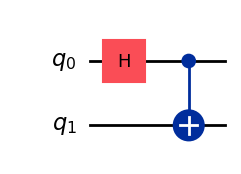

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_phi_plus = QuantumCircuit(2)

qc_phi_plus.h(0)
qc_phi_plus.cx(0, 1)

state_phi_plus = Statevector.from_instruction(qc_phi_plus)

print("Statevector:")
print(state_phi_plus.data)

print("\nProbabilities:")
print(state_phi_plus.probabilities_dict())

print("\nCircuit:")
qc_phi_plus.draw('mpl')
#print(qc_phi_plus)

### 8.2 From \(|\Phi^+\rangle\) to \(|\Phi^-\rangle\)

Compare:

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

with

$$
|\Phi^-\rangle
=
\frac{|00\rangle-|11\rangle}{\sqrt2}.
$$

The probabilities of the two computational-basis components have not changed.

Only their **relative phase** has changed.

We can produce this change using the Pauli-Z gate.

Starting with \(|\Phi^+\rangle\), apply Z to one of the qubits.

### Predict

Will direct computational-basis measurement distinguish \(|\Phi^+\rangle\) from \(|\Phi^-\rangle\)?

Explain your prediction before executing the circuit.


In [ ]:
qc_phi_minus = QuantumCircuit(2)

qc_phi_minus.h(0)
qc_phi_minus.cx(0, 1)
qc_phi_minus.z(0)

state_phi_minus = Statevector.from_instruction(qc_phi_minus)

print("Statevector:")
print(state_phi_minus.data)

print("\nProbabilities:")
print(state_phi_minus.probabilities_dict())

Statevector:
[ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]

Probabilities:
{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


## 8.3 From \(|\Phi^+\rangle\) to \(|\Psi^+\rangle\)

Now compare

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

with

$$
|\Psi^+\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt2}.
$$

This time we need to change the computational-basis components rather than only their phase.

Applying an X gate to one qubit flips that qubit:

$$
|00\rangle\rightarrow|10\rangle
$$

and

$$
|11\rangle\rightarrow|01\rangle
$$

when X is applied to \(q_1\).

Therefore,

$$
|\Phi^+\rangle
\rightarrow
|\Psi^+\rangle.
$$

### Predict

Which two computational-basis states should have non-zero amplitudes after applying X?


In [ ]:
qc_psi_plus = QuantumCircuit(2)

qc_psi_plus.h(0)
qc_psi_plus.cx(0, 1)
qc_psi_plus.x(1)

state_psi_plus = Statevector.from_instruction(qc_psi_plus)

print("Statevector:")
print(state_psi_plus.data)

print("\nProbabilities:")
print(state_psi_plus.probabilities_dict())

Statevector:
[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]

Probabilities:
{np.str_('01'): np.float64(0.4999999999999999), np.str_('10'): np.float64(0.4999999999999999)}


In [ ]:
qc_psi_minus = QuantumCircuit(2)

qc_psi_minus.h(0)
qc_psi_minus.cx(0, 1)

qc_psi_minus.x(1)
qc_psi_minus.z(0)

state_psi_minus = Statevector.from_instruction(qc_psi_minus)

print("Statevector:")
print(state_psi_minus.data)

print("\nProbabilities:")
print(state_psi_minus.probabilities_dict())

Statevector:
[ 0.        +0.j -0.70710678+0.j  0.70710678+0.j  0.        +0.j]

Probabilities:
{np.str_('01'): np.float64(0.4999999999999999), np.str_('10'): np.float64(0.4999999999999999)}


In [ ]:
print("Phi+ :", state_phi_plus.data)
print("Phi- :", state_phi_minus.data)
print("Psi+ :", state_psi_plus.data)
print("Psi- :", state_psi_minus.data)

Phi+ : [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Phi- : [ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]
Psi+ : [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
Psi- : [ 0.        +0.j -0.70710678+0.j  0.70710678+0.j  0.        +0.j]


## 8.5 Comparing the Four Bell States

The four Bell states differ in two ways:

| Bell state | Basis components | Relative phase |       |
| ---------- | ---------------- | -------------- | ----- |
| (          | \Phi^+\rangle)   | \(00,11\)      | \(+\) |
| (          | \Phi^-\rangle)   | \(00,11\)      | \(-\) |
| (          | \Psi^+\rangle)   | \(01,10\)      | \(+\) |
| (          | \Psi^-\rangle)   | \(01,10\)      | \(-\) |

This gives us two different kinds of quantum information:

### Bit information

The distinction

$$
\Phi \leftrightarrow \Psi
$$

changes which computational-basis outcomes occur.

### Phase information

The distinction

$$
+ \leftrightarrow -
$$

changes the **relative phase** between the amplitudes.

Computational-basis measurement can directly distinguish the \(\Phi\) family from the \(\Psi\) family:

$$
\Phi \rightarrow 00\text{ or }11
$$

$$
\Psi \rightarrow 01\text{ or }10.
$$

However, computational-basis measurement alone cannot distinguish

$$
\Phi^+ \text{ from } \Phi^-
$$

or

$$
\Psi^+ \text{ from } \Psi^-,
$$

because the sign affects phase rather than the computational-basis probabilities.


## 8.6 Can We Distinguish All Four Bell States?

Direct computational-basis measurement does not reveal all the information contained in a Bell state.

For example,

$$
|\Phi^+\rangle
$$

and

$$
|\Phi^-\rangle
$$

both produce

$$
00 \quad\text{or}\quad 11
$$

with equal probability.

Their difference is encoded in **relative phase**.

To reveal this information, we can transform the Bell state before measuring.

Apply:

1. CNOT with \(q_0\) as control and \(q_1\) as target.
2. H to \(q_0\).
3. Measure both qubits.

These operations reverse the Bell-state preparation process and convert the Bell states into computational-basis states that can be distinguished by measurement.


{np.str_('00'): np.float64(0.9999999999999996), np.str_('01'): np.float64(5.004680467665246e-34)}


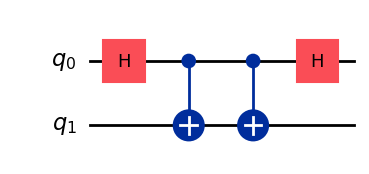

In [ ]:
qc = QuantumCircuit(2)

# Prepare Phi+
qc.h(0)
qc.cx(0, 1)

# Bell-state analysis
qc.cx(0, 1)
qc.h(0)

state = Statevector.from_instruction(qc)

print(state.probabilities_dict())
qc.draw('mpl')


## 8.7 Exercise — Build a Bell-State Analyzer

Prepare each of the four Bell states:

$$
|\Phi^+\rangle,\quad
|\Phi^-\rangle,\quad
|\Psi^+\rangle,\quad
|\Psi^-\rangle.
$$

For each state:

1. Write its mathematical expression.
2. Predict its statevector.
3. Obtain its statevector using Qiskit.
4. Predict its computational-basis measurement probabilities.
5. Apply the inverse Bell transformation:

$$
CX(q_0,q_1)
$$

followed by

$$
H(q_0).
$$

6. Determine which computational-basis state is obtained.
7. Measure the circuit and verify your prediction.

Complete the following table:

| Bell state | Before analyzer | After analyzer |                    |   |
| ---------- | --------------- | -------------- | ------------------ | - |
| \(\Phi^+\) | ((              | 00\rangle+     | 11\rangle)/\sqrt2) | ? |
| \(\Phi^-\) | ((              | 00\rangle-     | 11\rangle)/\sqrt2) | ? |
| \(\Psi^+\) | ((              | 01\rangle+     | 10\rangle)/\sqrt2) | ? |
| \(\Psi^-\) | ((              | 01\rangle-     | 10\rangle)/\sqrt2) | ? |

### Reflection

Why can the four Bell states not be completely distinguished by direct computational-basis measurement?

What role does the inverse Bell transformation play?


## 9. Extending Entanglement to Multiple Qubits

So far, we have studied entanglement using two qubits.

For example, the Bell state

$$
|\Phi^+\rangle
=
\frac{|00\rangle+|11\rangle}{\sqrt2}
$$

contains two entangled qubits.

Entanglement is not restricted to two-qubit systems. Multiple qubits can participate in a joint entangled state.

One of the most important examples is the three-qubit **GHZ state**:

$$
|GHZ\rangle
=
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

When measured in the computational basis, an ideal GHZ state produces only

$$
000
$$

or

$$
111,
$$

each with probability

$$
\frac12.
$$

The three measurement results are therefore perfectly correlated.

In this section, we will construct a GHZ state, examine its statevector, and analyze its measurement outcomes.


### 9.1 A Three-Qubit System

Create a quantum circuit containing three qubits:

$$
q_0,\quad q_1,\quad q_2.
$$

All three are initially in state \(|0\rangle\), giving

$$
|000\rangle.
$$

A three-qubit system has

$$
2^3=8
$$

computational-basis states:

$$
|000\rangle,\ |001\rangle,\ |010\rangle,\ |011\rangle,
$$

$$
|100\rangle,\ |101\rangle,\ |110\rangle,\ |111\rangle.
$$

Consequently, its statevector contains **eight complex amplitudes**.

As before, Qiskit displays three-qubit basis labels in the order

$$
q_2q_1q_0.
$$


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(3)

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state.data)

print("\nProbabilities:")
print(state.probabilities_dict())

Statevector:
[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Probabilities:
{np.str_('000'): np.float64(1.0)}


## 9.2 Constructing a GHZ State

Start with

$$
|000\rangle.
$$

### Step 1 — Create superposition

Apply H to \(q_0\):

$$
|000\rangle
\rightarrow
\frac{|000\rangle+|001\rangle}{\sqrt2}.
$$

### Step 2 — Correlate \(q_1\)

Apply

$$
CX(q_0,q_1).
$$

The state becomes

$$
\frac{|000\rangle+|011\rangle}{\sqrt2}.
$$

### Step 3 — Correlate \(q_2\)

Now apply

$$
CX(q_1,q_2).
$$

The state becomes

$$
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

This is the three-qubit GHZ state:

$$
|GHZ\rangle=
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

### Predict

Before executing the circuit:

1. How many amplitudes should be non-zero?
2. Which basis states should have non-zero amplitudes?
3. What should the magnitude of each non-zero amplitude be?
4. Which measurement outcomes should be possible?


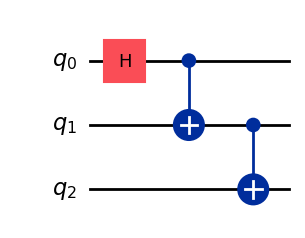

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_ghz = QuantumCircuit(3)

qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)

qc_ghz.draw('mpl')

In [ ]:
state_ghz = Statevector.from_instruction(qc_ghz)

print("GHZ Statevector:")
print(state_ghz.data)

print("\nProbabilities:")
print(state_ghz.probabilities_dict())

GHZ Statevector:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

Probabilities:
{np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}


## 9.3 Interpreting the GHZ Statevector

The GHZ statevector has eight positions because three qubits require

$$
2^3=8
$$

amplitudes.

However, only two amplitudes are non-zero:

$$
|000\rangle
\quad\text{and}\quad
|111\rangle.
$$

Each has amplitude

$$
\frac1{\sqrt2}.
$$

Therefore,

$$
P(000)
=
\left|\frac1{\sqrt2}\right|^2
=
\frac12
$$

and

$$
P(111)=\frac12.
$$

All other computational-basis outcomes have probability zero.

The state therefore represents a coherent superposition of two collective possibilities:

$$
\text{all three qubits are 0}
$$

and

$$
\text{all three qubits are 1}.
$$


In [ ]:
from qiskit.primitives import StatevectorSampler

qc_measure = qc_ghz.copy()
qc_measure.measure_all()

sampler = StatevectorSampler()

job = sampler.run([qc_measure], shots=10000)
result = job.result()

counts_ghz = result[0].data.meas.get_counts()

print(counts_ghz)

{'111': 4945, '000': 5055}


## 9.4 What Does Measurement Tell Us?

For an ideal GHZ state, only two outcomes occur:

$$
000
$$

and

$$
111.
$$

An individual shot is unpredictable.

For example, we cannot predict whether the next execution will produce `000` or `111`.

However, the relationship among the three measured qubits is predictable.

If one measurement gives

$$
0,
$$

all three give 0.

If one gives

$$
1,
$$

all three give 1.

Thus,

> **The individual outcome is probabilistic, while the three-qubit computational-basis correlation is perfect.**


## 9.5 Is This Just Three Qubits in Superposition?

Suppose instead that we apply H independently to all three qubits:

$$
H(q_0),\quad H(q_1),\quad H(q_2).
$$

The resulting state is

$$
|+\rangle|+\rangle|+\rangle.
$$

Expanding this product produces

$$
\frac{1}{\sqrt8}
(
|000\rangle+
|001\rangle+
|010\rangle+
|011\rangle+
|100\rangle+
|101\rangle+
|110\rangle+
|111\rangle
).
$$

All eight outcomes have probability

$$
\frac18.
$$

This is very different from the GHZ state, which has only

$$
000
$$

and

$$
111
$$

as computational-basis outcomes.

Let us verify the difference.


In [ ]:
qc_independent = QuantumCircuit(3)

qc_independent.h(0)
qc_independent.h(1)
qc_independent.h(2)

state_independent = Statevector.from_instruction(qc_independent)

print(state_independent.probabilities_dict())

{np.str_('000'): np.float64(0.12499999999999994), np.str_('001'): np.float64(0.12499999999999994), np.str_('010'): np.float64(0.12499999999999994), np.str_('011'): np.float64(0.12499999999999994), np.str_('100'): np.float64(0.12499999999999994), np.str_('101'): np.float64(0.12499999999999994), np.str_('110'): np.float64(0.12499999999999994), np.str_('111'): np.float64(0.12499999999999994)}


## 9.6 Experiment — Which Gates Are Essential?

The GHZ circuit contains three important operations:

$$
H(q_0)
$$

$$
CX(q_0,q_1)
$$

$$
CX(q_1,q_2).
$$

Investigate what happens when individual operations are removed.

### Experiment A

Remove

$$
H(q_0).
$$

Predict the final state before executing.

### Experiment B

Restore H but remove

$$
CX(q_1,q_2).
$$

Which qubits become correlated?

What happens to \(q_2\)?

### Experiment C

Apply H independently to all three qubits instead of using CNOT gates.

Does this produce the GHZ state?

### For each experiment

1. Predict the state.
2. Construct the circuit.
3. Obtain its statevector.
4. Calculate its probabilities.
5. Measure using 10,000 shots.
6. Explain the result.


## 9.7 Challenge — Construct a Four-Qubit GHZ State

The three-qubit GHZ state is

$$
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

Can you extend the same idea to four qubits?

Your target state is

$$
|GHZ_4\rangle
=
\frac{|0000\rangle+|1111\rangle}{\sqrt2}.
$$

### Task

Without looking at a completed circuit:

1. Create four qubits.
2. Determine where H should be applied.
3. Determine how many CNOT gates are required.
4. Decide the control and target for each CNOT.
5. Predict the statevector.
6. Predict the measurement probabilities.
7. Implement your circuit in Qiskit.
8. Verify your result using `Statevector`.
9. Measure the circuit using 10,000 shots.

### Generalization

Can you describe a procedure for preparing

$$
|GHZ_n\rangle
=
\frac{|00\ldots0\rangle+|11\ldots1\rangle}{\sqrt2}
$$

using \(n\) qubits?


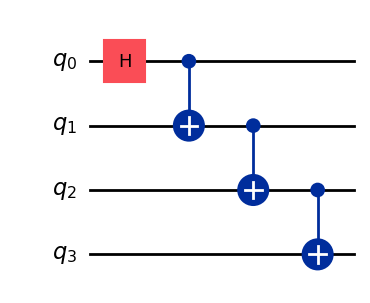

In [ ]:
n = 4

qc = QuantumCircuit(n)

qc.h(0)

for i in range(n - 1):
    qc.cx(i, i + 1)

qc.draw('mpl')

## 9.8 Key Takeaways

Entanglement can involve more than two qubits.

The three-qubit GHZ state is

$$
|GHZ\rangle
=
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$$

It can be constructed by:

1. creating superposition with H,
2. propagating correlations using controlled operations.

Its statevector contains eight amplitudes, but only the amplitudes corresponding to

$$
|000\rangle
$$

and

$$
|111\rangle
$$

are non-zero.

Computational-basis measurement produces approximately:

$$
000 \rightarrow 50\%
$$

$$
111 \rightarrow 50\%.
$$

We also observed that

$$
|+\rangle|+\rangle|+\rangle
$$

is fundamentally different from a GHZ state. Independent superpositions produce all eight computational-basis outcomes, whereas the GHZ state exhibits collective correlations.

Finally, the same circuit pattern can be generalized to

$$
|GHZ_n\rangle
=
\frac{|00\ldots0\rangle+|11\ldots1\rangle}{\sqrt2}.
$$

This demonstrates an important principle of quantum programming:

> **Quantum circuits can be constructed programmatically to create structured multi-qubit states of increasing size.**


# 10. Session 2 Competency Challenge

## Design, Construct and Analyze a Multi-Qubit Circuit

You have now learned how to:

* create multi-qubit quantum circuits,
* prepare computational-basis and product states,
* use controlled operations,
* create Bell states,
* distinguish superposition from entanglement,
* interpret multi-qubit statevectors,
* analyze measurement correlations,
* construct the four Bell states, and
* extend entanglement to three or more qubits.

In this final activity, you will combine these skills to solve a quantum-state preparation problem.

### Competency

> **I can design, construct, execute, and analyze a multi-qubit quantum circuit and explain the relationship between its circuit, statevector, and measurement outcomes.**

### Learning Cycle

**Predict → Design → Build → Analyze → Execute → Explain**

Do not begin with trial-and-error coding. First reason about the required quantum state.


## 10.1 Challenge 1 — Prepare the Target State

Your target state is

$$
|\psi_{\text{target}}\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt2}.
$$

### Part A — Analyze Before Coding

Answer the following without using Qiskit:

1. How many qubits are required?
2. Which computational-basis states have non-zero amplitudes?
3. What is the amplitude of \(|01\rangle\)?
4. What is the amplitude of \(|10\rangle\)?
5. What are the probabilities of `00`, `01`, `10`, and `11`?
6. Are the two qubits independent or entangled?
7. What measurement correlation do you expect?

Write the expected statevector:

$$
|\psi\rangle=
\begin{bmatrix}
?\\
?\\
?\\
?
\end{bmatrix}.
$$

### Part B — Design the Circuit

Starting from

$$
|00\rangle,
$$

design a circuit that produces

$$
\frac{|01\rangle+|10\rangle}{\sqrt2}.
$$

You may use:

* X
* H
* CNOT

Do not execute the circuit until you have drawn or described your proposed solution.

### Part C — Implement

Implement your circuit using `QuantumCircuit`.

Display the circuit using

`print(qc)`

and verify that it corresponds to your design.


In [ ]:
#@title My Hidden Setup Code
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.x(1)

print(qc)

     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘


## 10.2 Challenge 2 — Verify the Statevector

A correct circuit should prepare

$$
|\Psi^+\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt2}.
$$

Before executing the code, predict its statevector.

Remember the two-qubit basis ordering:

$$
|00\rangle,\quad|01\rangle,\quad|10\rangle,\quad|11\rangle.
$$

Then use `Statevector.from_instruction()` to obtain the actual statevector.

### Questions

1. Does the calculated statevector match your prediction?
2. Which amplitudes are zero?
3. Which amplitudes have magnitude \(1/\sqrt2\)?
4. Does the normalization condition hold?

Verify that

$$
|a|^2+|b|^2+|c|^2+|d|^2=1.
$$


In [ ]:
#@title My Hidden Setup Code
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print(state.data)
print(state.probabilities_dict())

[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
{np.str_('01'): np.float64(0.4999999999999999), np.str_('10'): np.float64(0.4999999999999999)}


## 10.3 Challenge 3 — Predict the Measurement Results

Do not execute the circuit yet.

For

$$
|\Psi^+\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt2},
$$

predict the results of 10,000 computational-basis measurements.

Complete the table:

| Outcome | Theoretical Probability | Approximate Expected Count |
| ------- | ----------------------: | -------------------------: |
| `00`    |                       ? |                          ? |
| `01`    |                       ? |                          ? |
| `10`    |                       ? |                          ? |
| `11`    |                       ? |                          ? |

### Think

If \(q_0\) is measured as 0, what should \(q_1\) be?

If \(q_0\) is measured as 1, what should \(q_1\) be?

Are these qubits **correlated** or **anti-correlated** in the computational basis?


In [ ]:
from qiskit.primitives import StatevectorSampler

qc_measure = qc.copy()
qc_measure.measure_all()

sampler = StatevectorSampler()

job = sampler.run([qc_measure], shots=10000)
result = job.result()

counts = result[0].data.meas.get_counts()

print(counts)

{'01': 5092, '10': 4908}


## 10.4 Compare Prediction with Observation

Compare your experimental counts with your theoretical prediction.

Calculate the observed relative frequencies:

$$
f(x)=\frac{\text{count}(x)}{\text{total shots}}.
$$

### Explain

1. Why are `00` and `11` absent on an ideal simulator?
2. Why are `01` and `10` approximately equally frequent?
3. Why are their counts normally not exactly 5,000 each?
4. What property of the state causes the two measured bits always to be different?
5. Does increasing the number of shots change the quantum state?


## 10.5 Challenge 5 — Three-Qubit Circuit Design

Now prepare the target state

$$
|\psi\rangle
=
\frac{|001\rangle+|110\rangle}{\sqrt2}.
$$

This state has not been constructed for you.

### Your Task

Design the complete solution.

You must:

1. Determine the number of required qubits.
2. Write the expected statevector.
3. Determine which amplitudes are non-zero.
4. Calculate the theoretical measurement probabilities.
5. Design an appropriate circuit.
6. Implement the circuit in Qiskit.
7. Obtain and inspect its statevector.
8. Verify the probabilities using `probabilities_dict()`.
9. Measure the circuit using 10,000 shots.
10. Compare observed frequencies with theoretical probabilities.
11. Explain whether the state is entangled.

### Constraint

Use only gates already studied in this course:

* X
* H
* CNOT

### Design Hint

Do not begin by guessing gates.

First ask:

> How is this target state related to the GHZ state

$$
\frac{|000\rangle+|111\rangle}{\sqrt2}?
$$

Then determine which transformation converts the GHZ basis components into the required basis components.


## 10.6 Explain Your Solution

For one of the target states constructed above, write a short technical explanation addressing all of the following:

### Initial State

What is the initial state of the quantum register?

### State Preparation

What does each gate do to the state?

Trace the state after every important operation.

### Statevector

Explain the non-zero amplitudes in the final statevector.

### Measurement

Derive the expected measurement probabilities from the amplitudes.

### Correlation

Explain the relationship among the measured qubits.

### Entanglement

Explain why the final state is or is not entangled.

Your explanation should connect:

$$
\boxed{
\text{Circuit}
\rightarrow
\text{Quantum State}
\rightarrow
\text{Statevector}
\rightarrow
\text{Probabilities}
\rightarrow
\text{Measurement}
}
$$


# Session 2 — Reflection

You began this session with a two-qubit register initialized in

$$
|00\rangle.
$$

You can now construct and reason about multi-qubit quantum states.

Before completing this lab, verify that you can answer the following questions without referring to the notebook:

1. Why does an \(n\)-qubit pure state require \(2^n\) amplitudes?
2. What is the difference between a product state and an entangled state?
3. What are the control and target qubits of a CNOT gate?
4. How do H and CNOT combine to create a Bell state?
5. Why does \(|\Phi^+\rangle\) produce only `00` and `11` in computational-basis measurement?
6. Why is \(|+\rangle|+\rangle\) not entangled?
7. How can a statevector reveal information that computational-basis probabilities alone cannot reveal?
8. What distinguishes the four Bell states?
9. How can Bell-state information be transformed into computational-basis information?
10. How can the Bell-state construction be generalized to a GHZ state?
11. Why does measurement correlation alone not necessarily prove that a state is quantum-entangled?
12. Given a target multi-qubit state, can you design a circuit to prepare it?

### Session Competency

You have achieved the Session 2 competency when you can:

> **Design, construct, execute, and analyze a multi-qubit quantum circuit, and explain its statevector, measurement probabilities, correlations, and entanglement.**
